The following is an example of how to utilize our Sen1Floods11 dataset for training a FCNN. In this example, we train and validate on hand-labeled chips of flood events. However, our dataset includes several other options that are detailed in the README. To replace the dataset, as outlined further below, simply replace the train, test, and validation split csv's, and download the corresponding dataset.

Authenticate Google Cloud Platform. Note that to run this code, you must connect your notebook runtime to a GPU.

In [1]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.11.0+cu130
True
Tesla T4


Install RasterIO

In [2]:
!pip install rasterio

Define a model checkpoint folder, for storing network checkpoints during training

Download train, test, and validation splits for both flood water. To download different train, test, and validation splits, simply replace these paths with the path to a csv containing the desired splits.

In [3]:
import torch
import torchvision
import rasterio
import numpy as np

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Rasterio:", rasterio.__version__)

PyTorch: 2.11.0+cu130
Torchvision: 0.26.0+cu130
Rasterio: 1.5.2


Download raw train, test, and validation data. In this example, we are downloading train, test, and validation data of flood images which are hand labeled. However, you can simply replace these paths with whichever dataset you would like to use - further documentation of the Sen1Floods11 dataset and organization is available in the README.

In [4]:
from pathlib import Path

ROOT = Path("/content/sen1floods11")
S1_DIR = ROOT / "S1"
LABEL_DIR = ROOT / "Labels"
SPLIT_DIR = ROOT / "splits"
CHECKPOINT_DIR = ROOT / "checkpoints"

for path in [S1_DIR, LABEL_DIR, SPLIT_DIR, CHECKPOINT_DIR]:
    path.mkdir(parents=True, exist_ok=True)

Define model training hyperparameters

In [5]:
!gsutil cp \
  gs://sen1floods11/v1.1/splits/flood_handlabeled/flood_train_data.csv \
  /content/sen1floods11/splits/

!gsutil cp \
  gs://sen1floods11/v1.1/splits/flood_handlabeled/flood_valid_data.csv \
  /content/sen1floods11/splits/

!gsutil cp \
  gs://sen1floods11/v1.1/splits/flood_handlabeled/flood_test_data.csv \
  /content/sen1floods11/splits/

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://sen1floods11/v1.1/splits/flood_handlabeled/flood_train_data.csv...
/ [1 files][ 13.3 KiB/ 13.3 KiB]                                                
Operation completed over 1 objects/13.3 KiB.                                     
Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://sen1floods11/v1.1/splits/flood_handlabeled/flood_valid_data.csv...
/ [1 files][  4.7 KiB/  4.7 KiB]                                                
Operation completed over 1 objects/4.7 KiB.                                   

Define functions to process and augment training and testing images

In [6]:
!gsutil -m rsync -r \
  gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand \
  /content/sen1floods11/S1

!gsutil -m rsync -r \
  gs://sen1floods11/v1.1/data/flood_events/HandLabeled/LabelHand \
  /content/sen1floods11/Labels

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.

both the source and destination. Your crcmod installation isn't using the
module's C extension, so checksumming will run very slowly. If this is your
first rsync since updating gsutil, this rsync can take significantly longer than
usual. For help installing the extension, please see "gsutil help crcmod".

Building synchronization state...
Starting synchronization...
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/Bolivia_314919_S1Hand.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/Bolivia_103757_S1Hand.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/Bolivia_23014_S1Hand.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/Bolivia_29029

In [7]:
print("S1:", len(list(S1_DIR.glob("*.tif"))))
print("Labels:", len(list(LABEL_DIR.glob("*.tif"))))
print("Splits:", list(SPLIT_DIR.glob("*.csv")))

S1: 446
Labels: 446
Splits: [PosixPath('/content/sen1floods11/splits/flood_train_data.csv'), PosixPath('/content/sen1floods11/splits/flood_valid_data.csv'), PosixPath('/content/sen1floods11/splits/flood_test_data.csv')]


Load *flood water* train, test, and validation data from splits. In this example, this is the data we will use to train our model.

In [8]:
import rasterio
import numpy as np

sample_path = next(S1_DIR.glob("*.tif"))

with rasterio.open(sample_path) as src:
    image = src.read()
    print("shape:", image.shape)
    print("dtype:", image.dtype)
    print("CRS:", src.crs)
    print("范围:", np.nanmin(image), np.nanmax(image))

shape: (2, 512, 512)
dtype: float32
CRS: EPSG:4326
范围: -47.56339 9.789984


Load training data and validation data. Note that here, we have chosen to train and validate our model on flood data. However, you can simply replace the load function call with one of the options defined above to load a different dataset.

In [9]:
import csv
import random
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode

class Sen1Floods11Dataset(Dataset):
    def __init__(self, split_csv, s1_dir, label_dir, training=False):
        self.s1_dir = Path(s1_dir)
        self.label_dir = Path(label_dir)
        self.training = training
        self.items = []

        with open(split_csv, newline="") as f:
            for row in csv.reader(f):
                s1_name = Path(row[0]).name
                label_name = Path(row[1]).name
                self.items.append((s1_name, label_name))

    def __len__(self):
        return len(self.items)

    def __getitem__(self, index):
        s1_name, label_name = self.items[index]

        with rasterio.open(self.s1_dir / s1_name) as src:
            image = src.read([1, 2]).astype(np.float32)

        with rasterio.open(self.label_dir / label_name) as src:
            mask = src.read(1).astype(np.int64)

        # 与官方Notebook一致
        image = np.nan_to_num(
            image,
            nan=0.0,
            posinf=1.0,
            neginf=-50.0,
        )
        image = np.clip(image, -50.0, 1.0)
        image = (image + 50.0) / 51.0

        mask[mask == -1] = 255

        image = torch.from_numpy(image)
        mask = torch.from_numpy(mask)

        if self.training:
            top = random.randint(0, image.shape[1] - 256)
            left = random.randint(0, image.shape[2] - 256)

            image = image[:, top:top + 256, left:left + 256]
            mask = mask[top:top + 256, left:left + 256]

            if random.random() < 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)

            if random.random() < 0.5:
                image = TF.vflip(image)
                mask = TF.vflip(mask)
        else:
            image = TF.resize(
                image,
                [512, 512],
                interpolation=InterpolationMode.BILINEAR,
                antialias=True,
            )
            mask = TF.resize(
                mask.unsqueeze(0),
                [512, 512],
                interpolation=InterpolationMode.NEAREST,
            ).squeeze(0)

        # 官方数据集统计量
        mean = torch.tensor([0.6851, 0.5235])[:, None, None]
        std = torch.tensor([0.0820, 0.1102])[:, None, None]
        image = (image - mean) / std

        return image.float(), mask.long()

Define the network. For our purposes, we use ResNet50. However, if you wish to test a different model framework, optimizer, or loss function you can simply replace those here.

In [10]:
train_dataset = Sen1Floods11Dataset(
    SPLIT_DIR / "flood_train_data.csv",
    S1_DIR,
    LABEL_DIR,
    training=True,
)

valid_dataset = Sen1Floods11Dataset(
    SPLIT_DIR / "flood_valid_data.csv",
    S1_DIR,
    LABEL_DIR,
    training=False,
)

test_dataset = Sen1Floods11Dataset(
    SPLIT_DIR / "flood_test_data.csv",
    S1_DIR,
    LABEL_DIR,
    training=False,
)

Define assessment metrics. For our purposes, we use overall accuracy and mean intersection over union. However, we also include functions for calculating true positives, false positives, true negatives, and false negatives.

In [11]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

In [12]:
images, masks = next(iter(train_loader))

print(images.shape)
print(masks.shape)
print(torch.unique(masks))

torch.Size([16, 2, 256, 256])
torch.Size([16, 256, 256])
tensor([  0,   1, 255])


Define training loop

In [13]:
import torch.nn as nn
from torchvision.models.segmentation import fcn_resnet50

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = fcn_resnet50(
    weights=None,
    weights_backbone=None,
    num_classes=2,
)

# 将RGB三通道输入改成VV/VH双通道
model.backbone.conv1 = nn.Conv2d(
    2,
    64,
    kernel_size=7,
    stride=2,
    padding=3,
    bias=False,
)

Define validation loop

In [14]:
def replace_bn_with_gn(module, num_groups=16):
    for name, child in module.named_children():
        if isinstance(child, nn.BatchNorm2d):
            groups = min(num_groups, child.num_features)

            while child.num_features % groups != 0:
                groups -= 1

            setattr(
                module,
                name,
                nn.GroupNorm(groups, child.num_features),
            )
        else:
            replace_bn_with_gn(child, num_groups)

replace_bn_with_gn(model)
model = model.to(device)

In [15]:
criterion = nn.CrossEntropyLoss(
    weight=torch.tensor([1.0, 8.0], device=device),
    ignore_index=255,
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-4,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=len(train_loader) * 10,
    T_mult=2,
)

Define testing loop (here, you can replace assessment metrics).

In [16]:
from tqdm.auto import tqdm

def run_epoch(model, loader, training):
    model.train(training)

    loss_sum = 0.0
    intersection = 0
    union = 0

    for images, masks in tqdm(loader, leave=False):
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            logits = model(images)["out"]
            loss = criterion(logits, masks)

            if training:
                loss.backward()
                optimizer.step()
                scheduler.step()

        prediction = logits.argmax(dim=1)
        valid = masks != 255
        water_pred = (prediction == 1) & valid
        water_true = (masks == 1) & valid

        intersection += (water_pred & water_true).sum().item()
        union += (water_pred | water_true).sum().item()
        loss_sum += loss.item()

    return {
        "loss": loss_sum / len(loader),
        "water_iou": intersection / max(union, 1),
    }

In [20]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

In [22]:
from tqdm.auto import tqdm
import torch

def run_epoch(model, loader, training):
    model.train(training)

    total_loss = 0.0
    intersection = 0
    union = 0
    correct = 0
    valid_pixels = 0

    for batch_images, batch_masks in tqdm(loader, leave=False):
        batch_images = batch_images.to(device, non_blocking=True)
        batch_masks = batch_masks.to(device, non_blocking=True)

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            logits = model(batch_images)["out"]
            loss = criterion(logits, batch_masks)

            if training:
                loss.backward()
                optimizer.step()
                scheduler.step()

        prediction = logits.argmax(dim=1)
        valid = batch_masks != 255

        water_prediction = (prediction == 1) & valid
        water_target = (batch_masks == 1) & valid

        intersection += (
            water_prediction & water_target
        ).sum().item()

        union += (
            water_prediction | water_target
        ).sum().item()

        correct += (
            (prediction == batch_masks) & valid
        ).sum().item()

        valid_pixels += valid.sum().item()
        total_loss += loss.item()

    return {
        "loss": total_loss / max(len(loader), 1),
        "water_iou": intersection / max(union, 1),
        "accuracy": correct / max(valid_pixels, 1),
    }

Define training and validation scheme

In [23]:
additional_epochs = 30
start_epoch = 2
best_iou = 0.2629
patience = 10
epochs_without_improvement = 0

history = []

for epoch in range(start_epoch, start_epoch + additional_epochs):
    train_metrics = run_epoch(
        model,
        train_loader,
        training=True,
    )

    valid_metrics = run_epoch(
        model,
        valid_loader,
        training=False,
    )

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_metrics["loss"],
        "train_iou": train_metrics["water_iou"],
        "valid_loss": valid_metrics["loss"],
        "valid_iou": valid_metrics["water_iou"],
        "valid_accuracy": valid_metrics["accuracy"],
    })

    print(
        f"epoch={epoch + 1} "
        f"train_loss={train_metrics['loss']:.4f} "
        f"train_iou={train_metrics['water_iou']:.4f} "
        f"valid_loss={valid_metrics['loss']:.4f} "
        f"valid_iou={valid_metrics['water_iou']:.4f} "
        f"valid_acc={valid_metrics['accuracy']:.4f}"
    )

    if valid_metrics["water_iou"] > best_iou:
        best_iou = valid_metrics["water_iou"]
        epochs_without_improvement = 0

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "best_valid_iou": best_iou,
            },
            CHECKPOINT_DIR / "best_fcn_resnet50.pt",
        )

        print(f"保存最佳模型，valid IoU={best_iou:.4f}")

    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print(f"连续 {patience} 个 epoch 未提升，提前停止")
        break

  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

epoch=3 train_loss=0.5091 train_iou=0.2483 valid_loss=0.4465 valid_iou=0.2966 valid_acc=0.7586
保存最佳模型，valid IoU=0.2966


  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

...

  0%|          | 0/23 [00:00<?, ?it/s]

epoch=26 train_loss=0.2736 train_iou=0.4798 valid_loss=0.2711 valid_iou=0.4589 valid_acc=0.8825


  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

epoch=27 train_loss=0.2982 train_iou=0.4439 valid_loss=0.2701 valid_iou=0.4657 valid_acc=0.8868
连续 10 个 epoch 未提升，提前停止


In [24]:
checkpoint_path = CHECKPOINT_DIR / "best_fcn_resnet50.pt"

checkpoint = torch.load(
    checkpoint_path,
    map_location=device,
)

model.load_state_dict(checkpoint["model_state_dict"])

print("最佳epoch:", checkpoint["epoch"])
print("最佳验证IoU:", checkpoint["best_valid_iou"])

最佳epoch: 17
最佳验证IoU: 0.5277363037348949


In [25]:
test_metrics = run_epoch(
    model,
    test_loader,
    training=False,
)

print(f"Test loss: {test_metrics['loss']:.4f}")
print(f"Test water IoU: {test_metrics['water_iou']:.4f}")
print(f"Test accuracy: {test_metrics['accuracy']:.4f}")

  0%|          | 0/23 [00:00<?, ?it/s]

Test loss: 0.3703
Test water IoU: 0.5736
Test accuracy: 0.9312


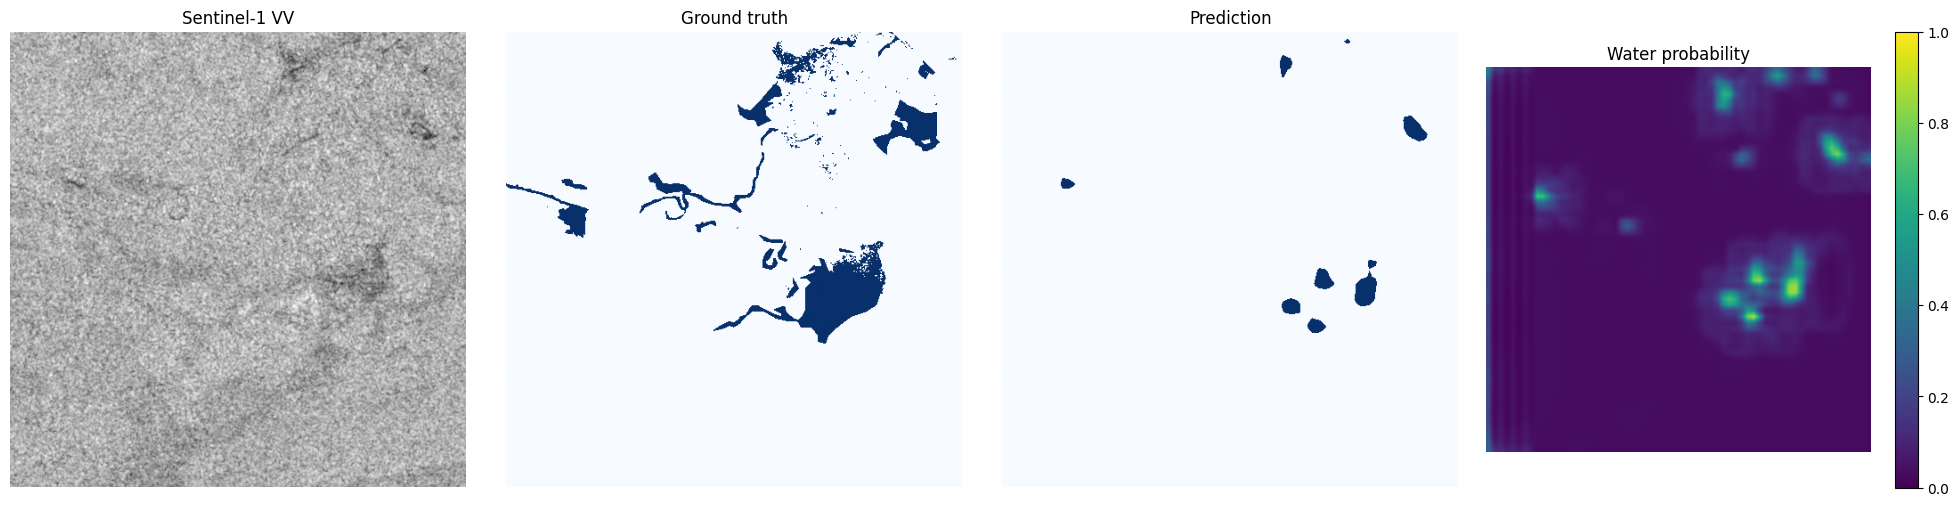

In [26]:
import matplotlib.pyplot as plt
import numpy as np

sample_image, sample_mask = test_dataset[0]

with torch.no_grad():
    logits = model(
        sample_image.unsqueeze(0).to(device)
    )["out"]

    probability = torch.softmax(logits, dim=1)[0, 1]
    prediction = logits.argmax(dim=1)[0]

# 反标准化，仅用于显示
vv = sample_image[0] * 0.0820 + 0.6851

mask_display = sample_mask.numpy().copy()
mask_display[mask_display == 255] = 0

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(vv.numpy(), cmap="gray")
axes[0].set_title("Sentinel-1 VV")

axes[1].imshow(mask_display, cmap="Blues", vmin=0, vmax=1)
axes[1].set_title("Ground truth")

axes[2].imshow(
    prediction.cpu().numpy(),
    cmap="Blues",
    vmin=0,
    vmax=1,
)
axes[2].set_title("Prediction")

im = axes[3].imshow(
    probability.cpu().numpy(),
    cmap="viridis",
    vmin=0,
    vmax=1,
)
axes[3].set_title("Water probability")
plt.colorbar(im, ax=axes[3])

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [27]:
def evaluate_binary_metrics(model, loader):
    model.eval()

    tp = fp = fn = tn = 0

    with torch.no_grad():
        for images, masks in tqdm(loader, leave=False):
            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)["out"]
            predictions = logits.argmax(dim=1)

            valid = masks != 255
            pred_water = (predictions == 1) & valid
            true_water = (masks == 1) & valid
            pred_land = (predictions == 0) & valid
            true_land = (masks == 0) & valid

            tp += (pred_water & true_water).sum().item()
            fp += (pred_water & true_land).sum().item()
            fn += (pred_land & true_water).sum().item()
            tn += (pred_land & true_land).sum().item()

    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-8)
    iou = tp / max(tp + fp + fn, 1)
    accuracy = (tp + tn) / max(tp + fp + fn + tn, 1)

    return {
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "water_iou": iou,
        "accuracy": accuracy,
    }

detailed_metrics = evaluate_binary_metrics(model, test_loader)

for name, value in detailed_metrics.items():
    if isinstance(value, float):
        print(f"{name}: {value:.4f}")
    else:
        print(f"{name}: {value}")

  0%|          | 0/23 [00:00<?, ?it/s]

TP: 1898007
FP: 742865
FN: 668094
TN: 17208401
precision: 0.7187
recall: 0.7396
f1: 0.7290
water_iou: 0.5736
accuracy: 0.9312


In [28]:
def single_image_result(index):
    image, mask = test_dataset[index]

    with torch.no_grad():
        logits = model(image.unsqueeze(0).to(device))["out"]
        probability = torch.softmax(logits, dim=1)[0, 1].cpu()
        prediction = logits.argmax(dim=1)[0].cpu()

    valid = mask != 255
    true_water = (mask == 1) & valid
    pred_water = (prediction == 1) & valid

    intersection = (true_water & pred_water).sum().item()
    union = (true_water | pred_water).sum().item()

    iou = intersection / max(union, 1)
    recall = intersection / max(true_water.sum().item(), 1)
    precision = intersection / max(pred_water.sum().item(), 1)

    return image, mask, prediction, probability, {
        "iou": iou,
        "precision": precision,
        "recall": recall,
    }

for index in range(min(10, len(test_dataset))):
    _, _, _, _, metrics = single_image_result(index)
    print(index, metrics)

0 {'iou': 0.13743736578382248, 'precision': 0.8295365278868814, 'recall': 0.14143172838679435}
1 {'iou': 0.05460750853242321, 'precision': 0.5797101449275363, 'recall': 0.05685856432125089}
2 {'iou': 0.0, 'precision': 0.0, 'recall': 0.0}
3 {'iou': 0.3493608090059149, 'precision': 0.5120246085011185, 'recall': 0.523741418764302}
4 {'iou': 0.5378348554926866, 'precision': 0.8817551963048499, 'recall': 0.5796412034108449}
5 {'iou': 0.6488622241268481, 'precision': 0.8761254484434672, 'recall': 0.7144029970463618}
6 {'iou': 0.6769724615644535, 'precision': 0.7128624799857677, 'recall': 0.9307781649245064}
7 {'iou': 0.0, 'precision': 0.0, 'recall': 0.0}
8 {'iou': 0.0, 'precision': 0.0, 'recall': 0.0}
9 {'iou': 0.0, 'precision': 0.0, 'recall': 0.0}


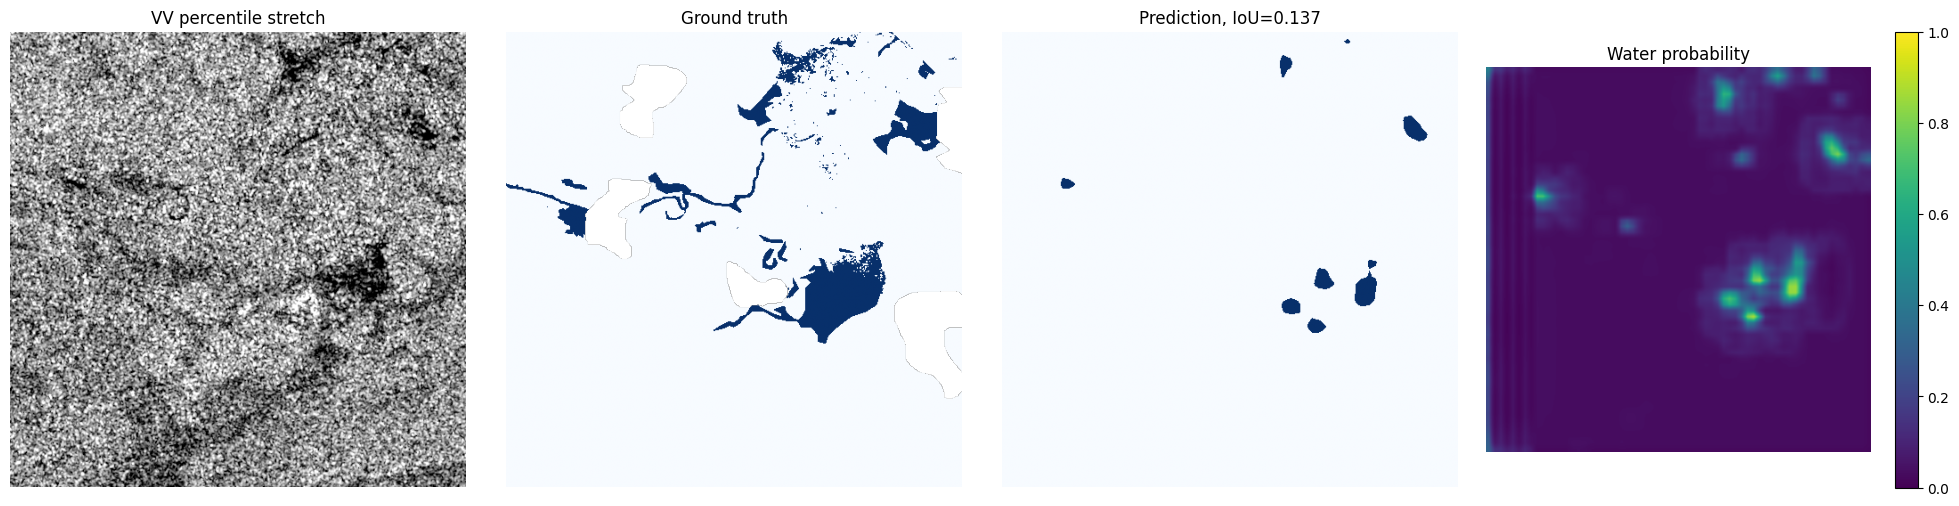

In [29]:
image, mask, prediction, probability, metrics = single_image_result(0)

vv_scaled = image[0] * 0.0820 + 0.6851
vv_scaled = vv_scaled.numpy()

low, high = np.percentile(vv_scaled, [2, 98])
vv_display = np.clip(
    (vv_scaled - low) / max(high - low, 1e-8),
    0,
    1,
)

mask_display = np.ma.masked_where(
    mask.numpy() == 255,
    mask.numpy(),
)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(vv_display, cmap="gray")
axes[0].set_title("VV percentile stretch")

axes[1].imshow(mask_display, cmap="Blues", vmin=0, vmax=1)
axes[1].set_title("Ground truth")

axes[2].imshow(prediction.numpy(), cmap="Blues", vmin=0, vmax=1)
axes[2].set_title(f"Prediction, IoU={metrics['iou']:.3f}")

im = axes[3].imshow(
    probability.numpy(),
    cmap="viridis",
    vmin=0,
    vmax=1,
)
axes[3].set_title("Water probability")
plt.colorbar(im, ax=axes[3])

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()